In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

In [2]:
df = pd.read_csv("flow_logs_data_synthetic.csv")

In [3]:
edges = (
    df[(df["FlowStatus"] == "Allowed")
       & df["SrcVm"].notna()
       & df["DestVm"].notna()]
    .copy()
)

# Strip the resource-group prefix for cleaner labels
edges["src"] = edges["SrcVm"].str.split("/").str[-1]
edges["dst"] = edges["DestVm"].str.split("/").str[-1]
edges["total_bytes"] = edges["BytesSrcToDest"].fillna(0) + edges["BytesDestToSrc"].fillna(0)

# Aggregate VM-to-VM flows
agg = (
    edges.groupby(["src", "dst"])
    .agg(flow_count=("src", "count"), total_bytes=("total_bytes", "sum"))
    .reset_index()
)

# ── Front Door synthetic edges ─────────────────────────────────────────────────
# External allowed port-80 traffic to web VMs = Front Door traffic
internet_to_fd = df[
    df["DestVm"].str.contains("web", na=False) &
    df["SrcVm"].isna() &
    (df["FlowStatus"] == "Allowed") &
    (df["DestPort"] == 80)
]
fd_flow_count = len(internet_to_fd)
fd_bytes = (internet_to_fd["BytesSrcToDest"].fillna(0) + internet_to_fd["BytesDestToSrc"].fillna(0)).sum()

# Front Door → each web VM
fd_to_web = internet_to_fd.copy()
fd_to_web["dst"] = fd_to_web["DestVm"].str.split("/").str[-1]
fd_to_web["total_bytes"] = fd_to_web["BytesSrcToDest"].fillna(0) + fd_to_web["BytesDestToSrc"].fillna(0)
fd_to_web_agg = fd_to_web.groupby("dst").agg(
    flow_count=("dst", "count"),
    total_bytes=("total_bytes", "sum")
).reset_index()
fd_to_web_agg["src"] = "Azure Front Door"

# Internet → Front Door synthetic row
internet_row = pd.DataFrame([{
    "src": "Internet",
    "dst": "Azure Front Door",
    "flow_count": fd_flow_count,
    "total_bytes": fd_bytes
}])

# Combine all edges
agg = pd.concat([agg, internet_row, fd_to_web_agg[["src","dst","flow_count","total_bytes"]]], ignore_index=True)
print(agg)

                 src                 dst  flow_count  total_bytes
0      flowdemo-app1  flowdemo-pgprimary           6     133600.0
1      flowdemo-app2  flowdemo-pgprimary           3      47517.0
2      flowdemo-app3  flowdemo-pgprimary           3      38593.0
3      flowdemo-app4  flowdemo-pgprimary           4      38596.0
4     flowdemo-applb       flowdemo-app1           3      64713.0
5     flowdemo-applb       flowdemo-app2           2      38827.8
6     flowdemo-applb       flowdemo-app3           1      12942.6
7     flowdemo-applb       flowdemo-app4           1      12942.6
8      flowdemo-web1      flowdemo-applb           3      43798.0
9      flowdemo-web2      flowdemo-applb           3      43798.0
10          Internet    Azure Front Door          32    9904282.0
11  Azure Front Door       flowdemo-web1          16    4952141.0
12  Azure Front Door       flowdemo-web2          16    4952141.0


In [4]:
G = nx.DiGraph()

for _, row in agg.iterrows():
    G.add_edge(
        row["src"],
        row["dst"],
        flow_count=int(row["flow_count"]),
        total_bytes=float(row["total_bytes"]),
    )

In [5]:
# ── 4. Derive visual weights ───────────────────────────────────────────────────
flows   = np.array([G[u][v]["flow_count"]   for u, v in G.edges()])
bytes_  = np.array([G[u][v]["total_bytes"]  for u, v in G.edges()])

# Edge width  → normalised flow count  (1 – 6 px range)
w_min, w_max = 1.0, 6.0
flow_range  = flows.max() - flows.min() if flows.max() != flows.min() else 1
edge_widths = w_min + (w_max - w_min) * (flows - flows.min()) / flow_range

# Edge colour → normalised byte volume (blue→red heat map)
norm        = mcolors.Normalize(vmin=bytes_.min(), vmax=bytes_.max())
cmap        = plt.colormaps["coolwarm"]
edge_colors = [cmap(norm(b)) for b in bytes_]

In [6]:
flows   = np.array([G[u][v]["flow_count"]   for u, v in G.edges()])
bytes_  = np.array([G[u][v]["total_bytes"]  for u, v in G.edges()])

# Edge width → normalised flow count (1–6 px range)
w_min, w_max = 1.0, 6.0
flow_range  = flows.max() - flows.min() if flows.max() != flows.min() else 1
edge_widths = w_min + (w_max - w_min) * (flows - flows.min()) / flow_range

# Edge colour → normalised byte volume (blue→red heat map)
norm        = mcolors.Normalize(vmin=bytes_.min(), vmax=bytes_.max())
cmap        = plt.colormaps["coolwarm"]
edge_colors = [cmap(norm(b)) for b in bytes_]

In [7]:
tier = {
    "Internet":             -1,
    "Azure Front Door":      0,
    "flowdemo-web1":         1,
    "flowdemo-web2":         1,
    "flowdemo-applb":        2,
    "flowdemo-app1":         3,
    "flowdemo-app2":         3,
    "flowdemo-app3":         3,
    "flowdemo-app4":         3,
    "flowdemo-pgprimary":    4,
    "flowdemo-pgsecondary":  4,
}

nodes_by_tier = {}
for node, t in tier.items():
    nodes_by_tier.setdefault(t, []).append(node)

pos = {}
for t, nodes in sorted(nodes_by_tier.items()):
    n = len(nodes)
    for i, node in enumerate(sorted(nodes)):
        pos[node] = ((i - (n - 1) / 2) * 2.5, -t * 2.0)

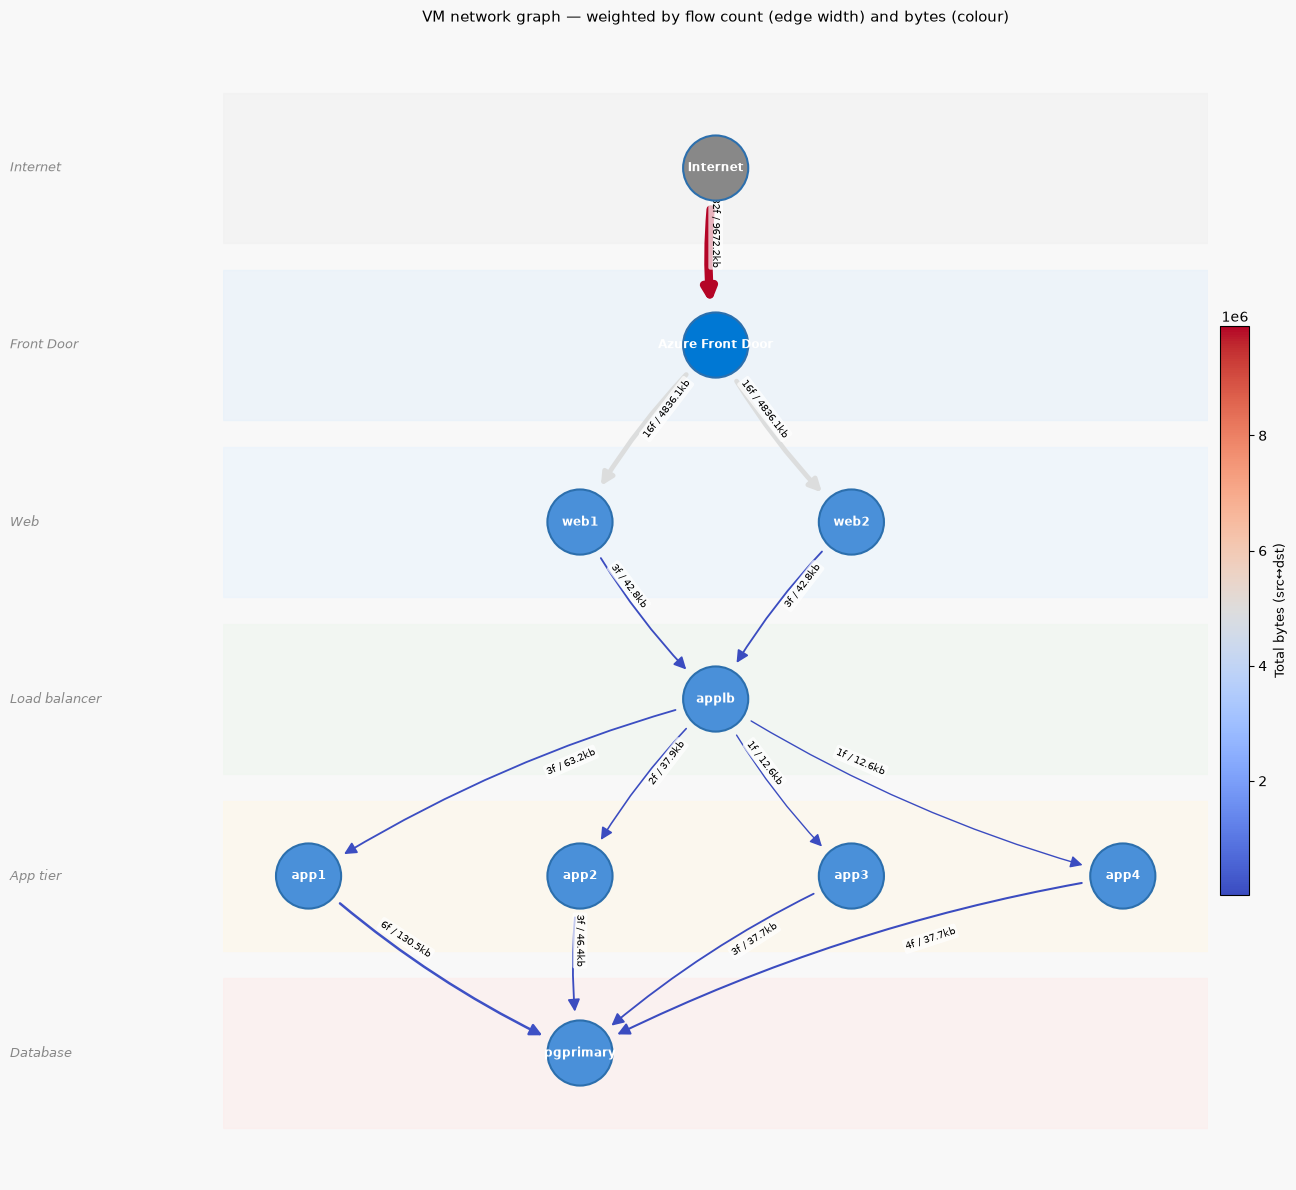

In [8]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor("#f8f8f8")
fig.patch.set_facecolor("#f8f8f8")

# Tier background bands
tier_labels = {-1: "Internet", 0: "Front Door", 1: "Web", 2: "Load balancer", 3: "App tier", 4: "Database"}
tier_colors = ["#f0f0f0", "#e3f0fb", "#e8f4fd", "#eef6ee", "#fff7e6", "#fdecea"]
for t, label in tier_labels.items():
    ys = [p[1] for node, p in pos.items() if tier.get(node) == t]
    if ys:
        y_c = np.mean(ys)
        ax.axhspan(y_c - 0.85, y_c + 0.85, color=tier_colors[list(tier_labels.keys()).index(t)], alpha=0.5, zorder=0)
        ax.text(-6.5, y_c, label, fontsize=9, color="#888", va="center", style="italic")

# Node colours: gray=Internet, Azure blue=Front Door, standard blue=VMs
node_colors = []
for node in G.nodes():
    if node == "Internet":
        node_colors.append("#888888")
    elif node == "Azure Front Door":
        node_colors.append("#0078d4")
    else:
        node_colors.append("#4a90d9")

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=2200,
    node_color=node_colors,
    linewidths=1.5,
    edgecolors="#2c6fad",
)

nx.draw_networkx_labels(
    G, pos, ax=ax,
    labels={n: n.replace("flowdemo-", "") for n in G.nodes()},
    font_size=8.5,
    font_color="white",
    font_weight="bold",
)

nx.draw_networkx_edges(
    G, pos, ax=ax,
    width=edge_widths,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.08",
    node_size=2200,
    min_source_margin=30,
    min_target_margin=30,
)

# Edge labels: "Nf flows / Xkb"
edge_labels = {
    (u, v): f"{d['flow_count']}f / {d['total_bytes']/1024:.1f}kb"
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_size=7.5, label_pos=0.35,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
)

# Colour bar for bytes
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Total bytes (src↔dst)", fontsize=9)

ax.set_title("VM network graph — weighted by flow count (edge width) and bytes (colour)",
             fontsize=11, pad=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# ── 7. SPOF analysis weighted by network traffic ───────────────────────────────
root = "Internet"
reachable_before = {root, *nx.descendants(G, root)} if root in G else set()
spof_rows = []
spof_names = set()

for candidate in sorted(reachable_before - {root}):
    G_removed = G.copy()
    G_removed.remove_node(candidate)

    reachable_after = {root, *nx.descendants(G_removed, root)} if root in G_removed else set()
    impacted_nodes = sorted((reachable_before - {candidate}) - reachable_after)

    if not impacted_nodes:
        continue

    affected_scope = {candidate, *impacted_nodes}
    affected_total_bytes = sum(
        data["total_bytes"]
        for u, v, data in G.edges(data=True)
        if u in affected_scope or v in affected_scope
    )

    spof_rows.append(
        {
            "spof": candidate,
            "failure_mode": "Transit dependency",
            "impacted_node_count": len(impacted_nodes),
            "impacted_nodes": ", ".join(impacted_nodes),
            "affected_total_bytes": affected_total_bytes,
        }
    )
    spof_names.add(candidate)

for candidate in sorted(reachable_before - {root}):
    if candidate in spof_names:
        continue

    predecessors = sorted(G.predecessors(candidate))
    successors = list(G.successors(candidate))

    if predecessors and not successors:
        inbound_total_bytes = sum(
            G[u][candidate]["total_bytes"]
            for u in predecessors
        )

        spof_rows.append(
            {
                "spof": candidate,
                "failure_mode": "Terminal data sink",
                "impacted_node_count": len(predecessors),
                "impacted_nodes": ", ".join(predecessors),
                "affected_total_bytes": inbound_total_bytes,
            }
        )
        spof_names.add(candidate)

spof_df = pd.DataFrame(spof_rows).sort_values(
    ["affected_total_bytes", "impacted_node_count", "spof"],
    ascending=[False, False, True],
).reset_index(drop=True)

if spof_df.empty:
    print("No single points of failure found from the Internet entry point.")
else:
    print("=== Single points of failure ranked by affected traffic ===")
    print(
        spof_df.to_string(index=False)
    )

    print("\nRules used:")
    print("1. Transit dependency: removing the node makes another node unreachable from Internet.")
    print("2. Terminal data sink: the node has inbound traffic, no downstream target, and is the end destination for application data.")

=== Single points of failure ranked by affected traffic ===
              spof       failure_mode  impacted_node_count                                                                                                               impacted_nodes  affected_total_bytes
  Azure Front Door Transit dependency                    8 flowdemo-app1, flowdemo-app2, flowdemo-app3, flowdemo-app4, flowdemo-applb, flowdemo-pgprimary, flowdemo-web1, flowdemo-web2            20283892.0
    flowdemo-applb Transit dependency                    5                                               flowdemo-app1, flowdemo-app2, flowdemo-app3, flowdemo-app4, flowdemo-pgprimary              475328.0
flowdemo-pgprimary Terminal data sink                    4                                                                   flowdemo-app1, flowdemo-app2, flowdemo-app3, flowdemo-app4              258306.0

Rules used:
1. Transit dependency: removing the node makes another node unreachable from Internet.
2. Terminal data

In [11]:
spof_df.to_csv("spof_analysis.csv", index=False)